## Preprocessing example

1. Load Data
2. Visualize data (EDA)
3. Clean data: remove columns and/or rows
4. X/y Split
5. train_test_split. (class only: if dataset is unbalanced, use stratify)
6. Fill/Encode/Scale Data: apply this only to the training set, then use those same parameters to transform the test set
7. Check Correlation Matrix on the scaled/encoded training data
8. Pick Model & Check Training Curve: Use the default settings on your training data (via Cross-Validation) to check for overfitting

(next steps omitted)

\9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)
\10. Train Final Model: Retrain the model on the entire training set using the best parameters found.
\11. View Results: use the test set to generate your Confusion Matrix, precision/recall/F1-score (class only), or R2, mse, mae (reg only)

## How to encode categories for RandomForest or HistGradientBoosting

* **RandomForest**: use one-hot encode, keep new encoded columns as int, not category

* **HistGradientBoosting**: instead of one-hot encoding convert columns with `astype('category')`, then use `model = HistGradientBoosting(**best_params, categorical_features='from_dtype')`

| **Feature Type**     | **RandomForest<br>(small dataset)**                                                                                   | **HistGradientBoosting<br>(large dataset)**                                                                                                              |
| -------------------- | --------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Continuous           | Leave as is. Trees are invariant to scaling; no need for StandardScaler.                                              | Leave as is. The algorithm automatically bins continuous values into histograms.                                                                         |
| Categorical (Binary) | Map to 0/1: `.map({'No': 0, 'Yes': 1})`                                    | Convert to category or keep as 0/1. Both work perfectly.                                                                                                 |
| Categorical (Few)    | One-Hot Encode. This allows the model to treat each category as a separate "on/off" switch.                           | Convert to category. The model will find the optimal split between categories natively.<br>Use `astype('category')` and `categorical_features='from_dtype'` |
| Categorical (Many)   | Target/Ordinal Encoding. Avoid One-Hot Encoding here; it creates too many columns, making the trees shallow and weak. | Convert to category. It handles high cardinality (up to 255 categories natively) much better than OHE.  |

---

In [1]:
# 1. Read CSV and load into dataframe

import pandas as pd

df = pd.read_csv("preprocess.csv")

df

,id,timestamp,temperature,humidity,city,device,target_class,energy_consumption
0,1,2024-03-26 15:00:00,30.406666,80.326630,Tokyo,Sensor_B,0,97.513592
1,2,2024-07-08 07:00:00,18.273757,69.068736,Tokyo,Sensor_B,0,59.528804
2,3,2024-08-02 23:00:00,28.666433,35.335695,London,Sensor_B,0,73.507854
3,4,2024-08-01 20:00:00,23.709832,65.580936,London,Sensor_B,0,81.858318
4,5,2024-06-10 06:00:00,21.934351,85.340882,London,Sensor_B,0,74.997384
...,...,...,...,...,...,...,...,...
495,496,2024-06-16 01:00:00,22.390849,59.565279,Paris,Sensor_B,0,68.260201
496,497,2024-01-14 15:00:00,26.149340,32.016226,Tokyo,Sensor_A,1,69.453723
497,498,2024-04-26 08:00:00,NaN,48.337483,Tokyo,Sensor_A,0,68.208705
498,499,2024-10-15 04:00:00,NaN,39.088035,Paris,Sensor_A,0,63.309870


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  500 non-null    int64  
 1   timestamp           500 non-null    object 
 2   temperature         450 non-null    float64
 3   humidity            500 non-null    float64
 4   city                475 non-null    object 
 5   device              500 non-null    object 
 6   target_class        500 non-null    int64  
 7   energy_consumption  500 non-null    float64
dtypes: float64(3), int64(2), object(3)
memory usage: 31.4+ KB


In [3]:
# Get column info

def get_column_info(df):
    """
    Returns a summary DataFrame with dtypes, null counts, 
    unique values for objects, and min/max for numeric columns.
    """
    summary_list = []
    
    for col in df.columns:

        # Basic info
        dtype = df[col].dtype
        null_count = df[col].isnull().sum()
        non_null_count = df[col].notnull().sum()
        
        unique_values = df[col].unique().tolist()
        min_val = None
        max_val = None
        
        # Info for numeric columns (Int/Float)
        if pd.api.types.is_numeric_dtype(dtype):
            min_val = df[col].min()
            max_val = df[col].max()
        # else: # Sort categorical unique values
            # unique_values = sorted(unique_values)
            
        summary_list.append({
            'Column': col,
            'Type': dtype,
            'Nulls': null_count,
            'Non-Nulls': non_null_count,
            'Unique Count': df[col].nunique(),
            'Unique Values': unique_values,
            'Min': min_val,
            'Max': max_val
        })

    return pd.DataFrame(summary_list).sort_values(by='Type')

get_column_info(df)

,Column,Type,Nulls,Non-Nulls,Unique Count,Unique Values,Min,Max
0,id,int64,0,500,500,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...",1.000000,500.000000
6,target_class,int64,0,500,2,"[0, 1]",0.000000,1.000000
2,temperature,float64,50,450,446,"[30.406666475968755, 18.27375694535462, 28.666...",10.589818,500.000000
3,humidity,float64,0,500,500,"[80.32662972427968, 69.06873582301031, 35.3356...",30.015951,89.911554
7,energy_consumption,float64,0,500,500,"[97.51359163713724, 59.528804132251466, 73.507...",43.224553,1088.622062
1,timestamp,object,0,500,486,"[2024-03-26 15:00:00, 2024-07-08 07:00:00, 202...",NaN,NaN
4,city,object,25,475,4,"[Tokyo, London, New York, Paris, nan]",NaN,NaN
5,device,object,0,500,2,"[Sensor_B, Sensor_A]",NaN,NaN


In [4]:
df.isna().sum()

id                     0
timestamp              0
temperature           50
humidity               0
city                  25
device                 0
target_class           0
energy_consumption     0
dtype: int64

In [5]:
# Check just the categorical columns

def get_all_categories(df):
    """Get names and unique values for every column with type 'object'"""

    obj_cols = df.select_dtypes(include=['object']).columns
    data = []

    for col in obj_cols:
        data.append({
            'column_name': col,
            'unique_values': df[col].unique().tolist(),
            'value_count': len(df[col].unique()),
        })
    
    return pd.DataFrame(data)

get_all_categories(df)

,column_name,unique_values,value_count
0,timestamp,"[2024-03-26 15:00:00, 2024-07-08 07:00:00, 202...",486
1,city,"[Tokyo, London, New York, Paris, nan]",5
2,device,"[Sensor_B, Sensor_A]",2


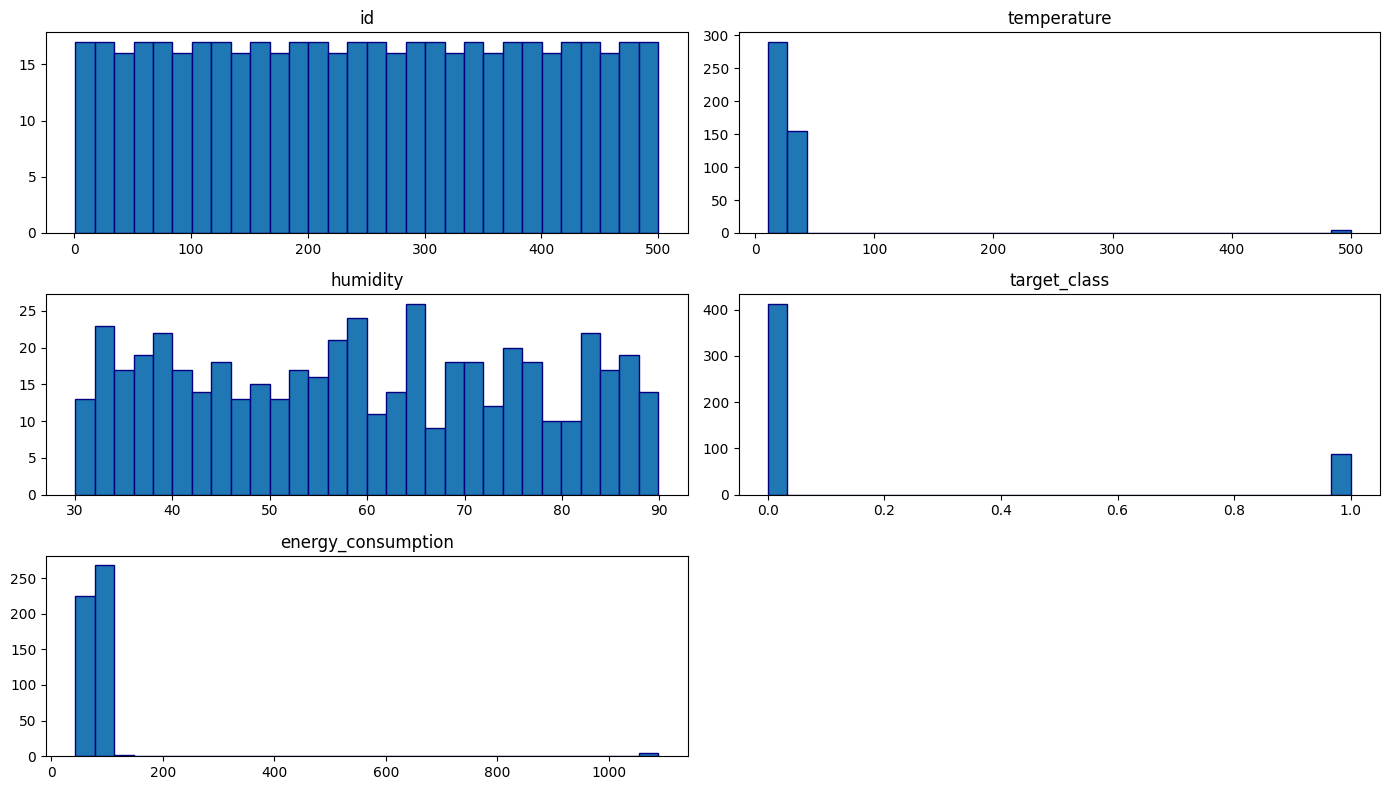

In [6]:
import matplotlib.pyplot as plt

def plot_histograms(df):
    '''Print histogram for all columns'''
    df.hist(figsize=(14, 8), bins=30, edgecolor='navy', grid=False)
    plt.tight_layout()
    plt.show()

plot_histograms(df)

C:\Users\VM\AppData\Local\Temp\ipykernel_16184\1925160718.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([num_df[col].dropna() for col in num_df.columns], labels=num_df.columns)


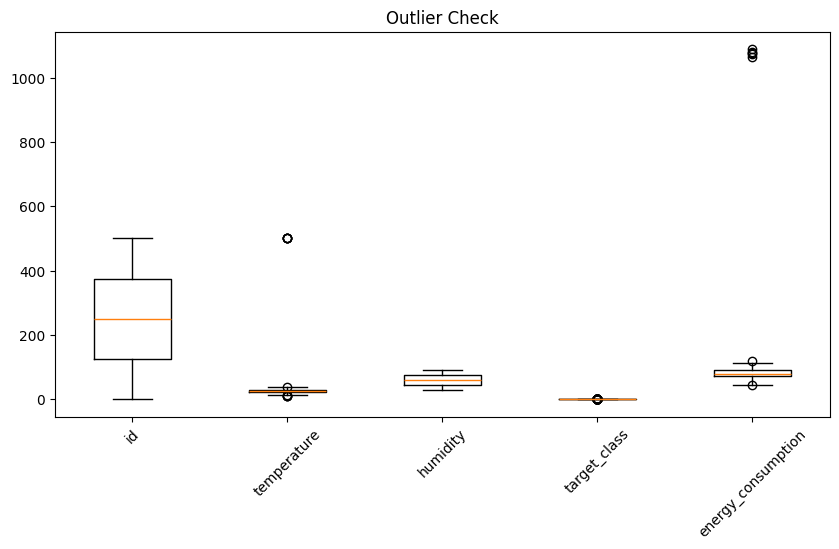

In [7]:
# 2. Analyze dataset with charts (Matplotlib)

import numpy as np
import matplotlib.pyplot as plt

def check_outliers(df):
    num_df = df.select_dtypes(include=[np.number])
    plt.figure(figsize=(10, 5))
    plt.boxplot([num_df[col].dropna() for col in num_df.columns], labels=num_df.columns)
    plt.title("Outlier Check")
    plt.xticks(rotation=45)
    plt.show()

check_outliers(df)

In [8]:
# 3. Feature Engineering: Hour and Cyclic Encoding

df_encoded = df.copy()
df_encoded["timestamp"] = pd.to_datetime(df_encoded["timestamp"])
df_encoded["hour"] = df_encoded["timestamp"].dt.hour
df_encoded["hour_sin"] = np.sin(2 * np.pi * df_encoded["hour"] / 24)
df_encoded["hour_cos"] = np.cos(2 * np.pi * df_encoded["hour"] / 24)

df_encoded

,id,timestamp,temperature,humidity,city,device,target_class,energy_consumption,hour,hour_sin,hour_cos
0,1,2024-03-26 15:00:00,30.406666,80.326630,Tokyo,Sensor_B,0,97.513592,15,-0.707107,-7.071068e-01
1,2,2024-07-08 07:00:00,18.273757,69.068736,Tokyo,Sensor_B,0,59.528804,7,0.965926,-2.588190e-01
2,3,2024-08-02 23:00:00,28.666433,35.335695,London,Sensor_B,0,73.507854,23,-0.258819,9.659258e-01
3,4,2024-08-01 20:00:00,23.709832,65.580936,London,Sensor_B,0,81.858318,20,-0.866025,5.000000e-01
4,5,2024-06-10 06:00:00,21.934351,85.340882,London,Sensor_B,0,74.997384,6,1.000000,6.123234e-17
...,...,...,...,...,...,...,...,...,...,...,...
495,496,2024-06-16 01:00:00,22.390849,59.565279,Paris,Sensor_B,0,68.260201,1,0.258819,9.659258e-01
496,497,2024-01-14 15:00:00,26.149340,32.016226,Tokyo,Sensor_A,1,69.453723,15,-0.707107,-7.071068e-01
497,498,2024-04-26 08:00:00,NaN,48.337483,Tokyo,Sensor_A,0,68.208705,8,0.866025,-5.000000e-01
498,499,2024-10-15 04:00:00,NaN,39.088035,Paris,Sensor_A,0,63.309870,4,0.866025,5.000000e-01


In [9]:
df_clean = df_encoded.copy()

# 4. Remove unnecessary columns
df_clean = df_clean.drop(columns=["id", "timestamp", "hour"], errors="ignore")

# 5. Remove certain rows if too many variables are missing
# Drop rows with more than 30% missing data
df_clean = df_clean.dropna(thresh=int(df.shape[1] * 0.7))

df_clean

,temperature,humidity,city,device,target_class,energy_consumption,hour_sin,hour_cos
0,30.406666,80.326630,Tokyo,Sensor_B,0,97.513592,-0.707107,-7.071068e-01
1,18.273757,69.068736,Tokyo,Sensor_B,0,59.528804,0.965926,-2.588190e-01
2,28.666433,35.335695,London,Sensor_B,0,73.507854,-0.258819,9.659258e-01
3,23.709832,65.580936,London,Sensor_B,0,81.858318,-0.866025,5.000000e-01
4,21.934351,85.340882,London,Sensor_B,0,74.997384,1.000000,6.123234e-17
...,...,...,...,...,...,...,...,...
495,22.390849,59.565279,Paris,Sensor_B,0,68.260201,0.258819,9.659258e-01
496,26.149340,32.016226,Tokyo,Sensor_A,1,69.453723,-0.707107,-7.071068e-01
497,NaN,48.337483,Tokyo,Sensor_A,0,68.208705,0.866025,-5.000000e-01
498,NaN,39.088035,Paris,Sensor_A,0,63.309870,0.866025,5.000000e-01


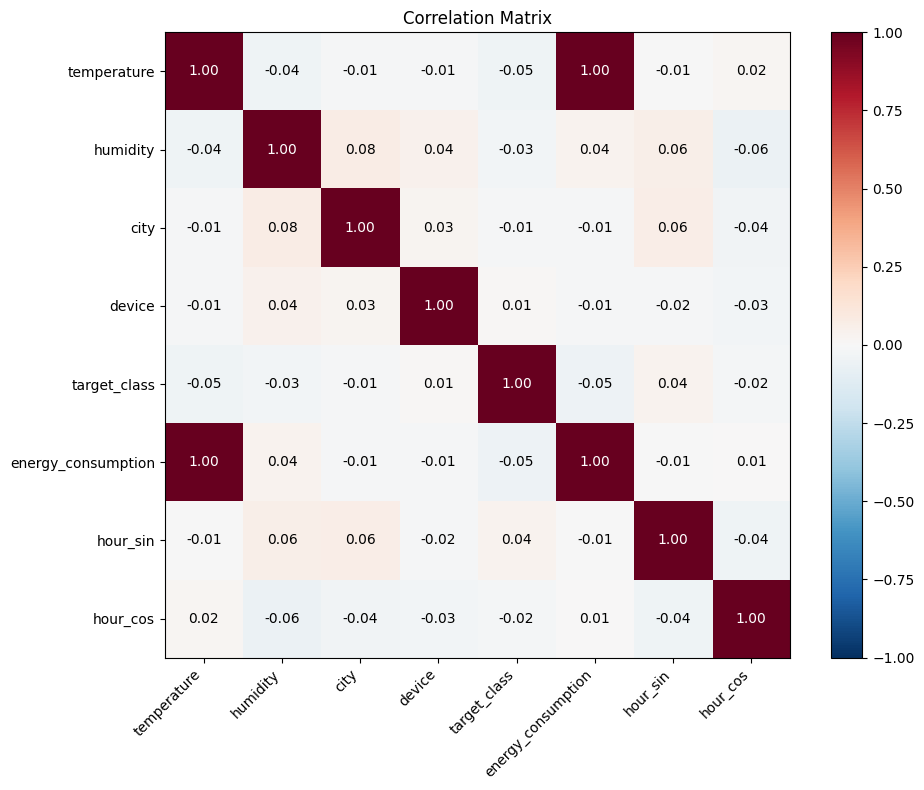

In [10]:
# 6. Check correlation matrix ("Rough" encoding on copy)

def show_correlation_matrix(df: pd.DataFrame):
    """
    Pure Matplotlib heatmap with automated text coloring for readability.
    """
    import matplotlib.pyplot as plt
    import numpy as np

    corr = df.corr()
    fig, ax = plt.subplots(figsize=(10, 8))

    # Use 'RdBu_r' (reversed) so Red is positive, Blue is negative
    im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
    plt.colorbar(im)

    # Labels
    ticks = np.arange(len(corr.columns))
    ax.set_xticks(ticks)
    ax.set_xticklabels(corr.columns, rotation=45, ha="right")
    ax.set_yticks(ticks)
    ax.set_yticklabels(corr.columns)

    # Add text annotations with contrast logic
    for i in range(len(corr.columns)):
        for j in range(len(corr.columns)):
            val = corr.iloc[i, j]
            # Use white text for very dark colors (strong correlations)
            color = "white" if abs(val) > 0.7 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color)

    ax.set_title("Correlation Matrix")
    fig.tight_layout()
    plt.show()


df_temp = df_clean.copy()
for col in df_temp.select_dtypes(include=["object"]).columns:
    df_temp[col] = df_temp[col].astype("category").cat.codes
show_correlation_matrix(df_temp)

In [11]:
# 7. Split X and y

target = "target_class"
X = df_clean.drop(columns=[target])
y = df_clean[target]

display(X, y)

,temperature,humidity,city,device,energy_consumption,hour_sin,hour_cos
0,30.406666,80.326630,Tokyo,Sensor_B,97.513592,-0.707107,-7.071068e-01
1,18.273757,69.068736,Tokyo,Sensor_B,59.528804,0.965926,-2.588190e-01
2,28.666433,35.335695,London,Sensor_B,73.507854,-0.258819,9.659258e-01
3,23.709832,65.580936,London,Sensor_B,81.858318,-0.866025,5.000000e-01
4,21.934351,85.340882,London,Sensor_B,74.997384,1.000000,6.123234e-17
...,...,...,...,...,...,...,...
495,22.390849,59.565279,Paris,Sensor_B,68.260201,0.258819,9.659258e-01
496,26.149340,32.016226,Tokyo,Sensor_A,69.453723,-0.707107,-7.071068e-01
497,NaN,48.337483,Tokyo,Sensor_A,68.208705,0.866025,-5.000000e-01
498,NaN,39.088035,Paris,Sensor_A,63.309870,0.866025,5.000000e-01


0      0
1      0
2      0
3      0
4      0
      ..
495    0
496    1
497    0
498    0
499    0
Name: target_class, Length: 500, dtype: int64

In [12]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         450 non-null    float64
 1   humidity            500 non-null    float64
 2   city                475 non-null    object 
 3   device              500 non-null    object 
 4   energy_consumption  500 non-null    float64
 5   hour_sin            500 non-null    float64
 6   hour_cos            500 non-null    float64
dtypes: float64(5), object(2)
memory usage: 27.5+ KB


In [13]:
# Check for target imbalance
y.value_counts()

target_class
0    413
1     87
Name: count, dtype: int64

In [14]:
# 8. Split X and y into train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y, 
    test_size=0.15,
    stratify=y, # classification only
)

display(X_train, X_test)

,temperature,humidity,city,device,energy_consumption,hour_sin,hour_cos
90,27.462575,35.994757,Tokyo,Sensor_A,72.516759,0.965926,2.588190e-01
297,16.522429,78.530644,London,Sensor_B,57.583173,-0.965926,-2.588190e-01
434,30.938817,69.073802,London,Sensor_B,103.990097,-0.500000,8.660254e-01
189,NaN,48.194431,Paris,Sensor_B,75.351496,1.000000,6.123234e-17
309,24.675920,32.536946,Paris,Sensor_B,59.390228,0.707107,7.071068e-01
...,...,...,...,...,...,...,...
165,13.175993,76.041798,Tokyo,Sensor_A,63.130178,0.707107,7.071068e-01
162,34.765124,33.415502,New York,Sensor_B,91.434599,0.258819,9.659258e-01
93,22.591033,52.467758,London,Sensor_A,71.908883,0.258819,9.659258e-01
192,20.439685,79.597845,New York,Sensor_B,84.330584,-0.866025,-5.000000e-01


,temperature,humidity,city,device,energy_consumption,hour_sin,hour_cos
495,22.390849,59.565279,Paris,Sensor_B,68.260201,0.258819,0.965926
18,31.856046,30.974762,Paris,Sensor_A,78.833130,-0.866025,0.500000
17,20.700627,42.929943,Paris,Sensor_A,54.415077,0.258819,0.965926
20,24.761761,48.021343,London,Sensor_B,75.004472,0.258819,0.965926
497,NaN,48.337483,Tokyo,Sensor_A,68.208705,0.866025,-0.500000
...,...,...,...,...,...,...,...
52,28.489774,70.841113,London,Sensor_A,86.661355,0.707107,0.707107
86,17.463684,69.532277,New York,Sensor_A,63.995775,-0.707107,-0.707107
19,33.258981,31.302324,New York,Sensor_B,81.675258,-0.707107,-0.707107
44,21.238662,80.028713,London,Sensor_A,84.366363,0.500000,0.866025


In [15]:
# 9. Fill in missing values

numerical_cols = X_train.select_dtypes(include=[np.number]).columns
category_cols = X_train.select_dtypes(include=["object"]).columns

# Fit on train
train_medians = X_train[numerical_cols].median()
train_modes = X_train[category_cols].mode().iloc[0]

# Transform train and test
X_train[numerical_cols] = X_train[numerical_cols].fillna(train_medians)
X_test[numerical_cols] = X_test[numerical_cols].fillna(train_medians)
X_train[category_cols] = X_train[category_cols].fillna(train_modes)
X_test[category_cols] = X_test[category_cols].fillna(train_modes)

display(X_train, X_test)

,temperature,humidity,city,device,energy_consumption,hour_sin,hour_cos
90,27.462575,35.994757,Tokyo,Sensor_A,72.516759,0.965926,2.588190e-01
297,16.522429,78.530644,London,Sensor_B,57.583173,-0.965926,-2.588190e-01
434,30.938817,69.073802,London,Sensor_B,103.990097,-0.500000,8.660254e-01
189,25.378873,48.194431,Paris,Sensor_B,75.351496,1.000000,6.123234e-17
309,24.675920,32.536946,Paris,Sensor_B,59.390228,0.707107,7.071068e-01
...,...,...,...,...,...,...,...
165,13.175993,76.041798,Tokyo,Sensor_A,63.130178,0.707107,7.071068e-01
162,34.765124,33.415502,New York,Sensor_B,91.434599,0.258819,9.659258e-01
93,22.591033,52.467758,London,Sensor_A,71.908883,0.258819,9.659258e-01
192,20.439685,79.597845,New York,Sensor_B,84.330584,-0.866025,-5.000000e-01


,temperature,humidity,city,device,energy_consumption,hour_sin,hour_cos
495,22.390849,59.565279,Paris,Sensor_B,68.260201,0.258819,0.965926
18,31.856046,30.974762,Paris,Sensor_A,78.833130,-0.866025,0.500000
17,20.700627,42.929943,Paris,Sensor_A,54.415077,0.258819,0.965926
20,24.761761,48.021343,London,Sensor_B,75.004472,0.258819,0.965926
497,25.378873,48.337483,Tokyo,Sensor_A,68.208705,0.866025,-0.500000
...,...,...,...,...,...,...,...
52,28.489774,70.841113,London,Sensor_A,86.661355,0.707107,0.707107
86,17.463684,69.532277,New York,Sensor_A,63.995775,-0.707107,-0.707107
19,33.258981,31.302324,New York,Sensor_B,81.675258,-0.707107,-0.707107
44,21.238662,80.028713,London,Sensor_A,84.366363,0.500000,0.866025


In [16]:
# Check that there are no missing values
X_train.isna().sum()

temperature           0
humidity              0
city                  0
device                0
energy_consumption    0
hour_sin              0
hour_cos              0
dtype: int64

In [17]:
# 10. Encode text columns with OneHotEncoder

from sklearn.preprocessing import OneHotEncoder


def one_hot_encode(X_train, X_test, columns_to_encode: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    
    """Applies one-hot encoding to the specified columns"""

    X_train_encoded = X_train.copy()
    X_test_encoded = X_test.copy()

    one_hot_encoder = OneHotEncoder(
        dtype=int,
        sparse_output=False,  # Output a full matrix of 0 and 1 instead of a lightweight "sparse" matrix of just ones
        handle_unknown="ignore",
    ).set_output(transform="pandas")

    new_encoded_columns = one_hot_encoder.fit_transform(X_train[columns_to_encode])

    # Add the new columns to the original dataframe
    X_train_encoded = pd.concat(
        [
            X_train_encoded.reset_index(drop=True),
            new_encoded_columns.reset_index(drop=True),
        ],
        axis=1,
    )

    # Add the new columns to the original dataframe
    new_encoded_columns = one_hot_encoder.transform(X_test[columns_to_encode])
    X_test_encoded = pd.concat(
        [
            X_test_encoded.reset_index(drop=True),
            new_encoded_columns.reset_index(drop=True),
        ],
        axis=1,
    )  # Add the new columns to the original dataframe

    # Remove original unencoded columns
    X_train_encoded = X_train_encoded.drop(columns=columns_to_encode)
    X_test_encoded = X_test_encoded.drop(columns=columns_to_encode)

    return X_train_encoded, X_test_encoded


X_train_encoded, X_test_encoded = one_hot_encode(X_train, X_test, columns_to_encode=category_cols)

display(X_train_encoded, X_test_encoded)

,temperature,humidity,energy_consumption,hour_sin,hour_cos,city_London,city_New York,city_Paris,city_Tokyo,device_Sensor_A,device_Sensor_B
0,27.462575,35.994757,72.516759,0.965926,2.588190e-01,0,0,0,1,1,0
1,16.522429,78.530644,57.583173,-0.965926,-2.588190e-01,1,0,0,0,0,1
2,30.938817,69.073802,103.990097,-0.500000,8.660254e-01,1,0,0,0,0,1
3,25.378873,48.194431,75.351496,1.000000,6.123234e-17,0,0,1,0,0,1
4,24.675920,32.536946,59.390228,0.707107,7.071068e-01,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
420,13.175993,76.041798,63.130178,0.707107,7.071068e-01,0,0,0,1,1,0
421,34.765124,33.415502,91.434599,0.258819,9.659258e-01,0,1,0,0,0,1
422,22.591033,52.467758,71.908883,0.258819,9.659258e-01,1,0,0,0,1,0
423,20.439685,79.597845,84.330584,-0.866025,-5.000000e-01,0,1,0,0,0,1


,temperature,humidity,energy_consumption,hour_sin,hour_cos,city_London,city_New York,city_Paris,city_Tokyo,device_Sensor_A,device_Sensor_B
0,22.390849,59.565279,68.260201,0.258819,0.965926,0,0,1,0,0,1
1,31.856046,30.974762,78.833130,-0.866025,0.500000,0,0,1,0,1,0
2,20.700627,42.929943,54.415077,0.258819,0.965926,0,0,1,0,1,0
3,24.761761,48.021343,75.004472,0.258819,0.965926,1,0,0,0,0,1
4,25.378873,48.337483,68.208705,0.866025,-0.500000,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
70,28.489774,70.841113,86.661355,0.707107,0.707107,1,0,0,0,1,0
71,17.463684,69.532277,63.995775,-0.707107,-0.707107,0,1,0,0,1,0
72,33.258981,31.302324,81.675258,-0.707107,-0.707107,0,1,0,0,0,1
73,21.238662,80.028713,84.366363,0.500000,0.866025,1,0,0,0,1,0


In [18]:
X_train_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 425 entries, 0 to 424
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   temperature         425 non-null    float64
 1   humidity            425 non-null    float64
 2   energy_consumption  425 non-null    float64
 3   hour_sin            425 non-null    float64
 4   hour_cos            425 non-null    float64
 5   city_London         425 non-null    int64  
 6   city_New York       425 non-null    int64  
 7   city_Paris          425 non-null    int64  
 8   city_Tokyo          425 non-null    int64  
 9   device_Sensor_A     425 non-null    int64  
 10  device_Sensor_B     425 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 36.7 KB


In [23]:
# 11. Standard Scaling (not required for tree-based models)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

X_train_scaled

,temperature,humidity,energy_consumption,hour_sin,hour_cos,city_London,city_New York,city_Paris,city_Tokyo,device_Sensor_A,device_Sensor_B
0,0.133859,-0.351905,0.056839,-0.316263,1.312508,1.915810,-0.551073,-0.558326,-0.678588,0.933941,-0.933941
1,-0.092741,-0.295220,-0.058594,-0.316263,-1.467058,1.915810,-0.551073,-0.558326,-0.678588,0.933941,-0.933941
2,0.015521,-0.898769,-0.055747,-0.652988,1.168771,-0.521972,1.814643,-0.558326,-0.678588,0.933941,-0.933941
3,-0.058353,-0.119006,-0.126752,0.743162,1.168771,-0.521972,-0.551073,-0.558326,1.473649,-1.070731,1.070731
4,-0.202256,1.381860,-0.054579,0.743162,1.168771,-0.521972,-0.551073,-0.558326,1.473649,-1.070731,1.070731
...,...,...,...,...,...,...,...,...,...,...,...
420,-0.092741,-0.617212,-0.206315,1.254189,-0.796680,-0.521972,-0.551073,-0.558326,1.473649,0.933941,-0.933941
421,-0.269523,1.412107,-0.137819,1.032315,-1.094667,-0.521972,-0.551073,-0.558326,1.473649,-1.070731,1.070731
422,-0.058473,0.747948,-0.000333,1.393665,-0.449666,-0.521972,-0.551073,-0.558326,1.473649,-1.070731,1.070731
423,-0.008209,-1.221945,-0.084238,1.254189,0.642130,-0.521972,-0.551073,1.791067,-0.678588,-1.070731,1.070731


In [24]:
# Preprocess complete

# Train the model and score results (omitted)

In [19]:
display(X_train_encoded, X_test_encoded)

,temperature,humidity,energy_consumption,hour_sin,hour_cos,city_London,city_New York,city_Paris,city_Tokyo,device_Sensor_A,device_Sensor_B
0,27.462575,35.994757,72.516759,0.965926,2.588190e-01,0,0,0,1,1,0
1,16.522429,78.530644,57.583173,-0.965926,-2.588190e-01,1,0,0,0,0,1
2,30.938817,69.073802,103.990097,-0.500000,8.660254e-01,1,0,0,0,0,1
3,25.378873,48.194431,75.351496,1.000000,6.123234e-17,0,0,1,0,0,1
4,24.675920,32.536946,59.390228,0.707107,7.071068e-01,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
420,13.175993,76.041798,63.130178,0.707107,7.071068e-01,0,0,0,1,1,0
421,34.765124,33.415502,91.434599,0.258819,9.659258e-01,0,1,0,0,0,1
422,22.591033,52.467758,71.908883,0.258819,9.659258e-01,1,0,0,0,1,0
423,20.439685,79.597845,84.330584,-0.866025,-5.000000e-01,0,1,0,0,0,1


,temperature,humidity,energy_consumption,hour_sin,hour_cos,city_London,city_New York,city_Paris,city_Tokyo,device_Sensor_A,device_Sensor_B
0,22.390849,59.565279,68.260201,0.258819,0.965926,0,0,1,0,0,1
1,31.856046,30.974762,78.833130,-0.866025,0.500000,0,0,1,0,1,0
2,20.700627,42.929943,54.415077,0.258819,0.965926,0,0,1,0,1,0
3,24.761761,48.021343,75.004472,0.258819,0.965926,1,0,0,0,0,1
4,25.378873,48.337483,68.208705,0.866025,-0.500000,0,0,0,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
70,28.489774,70.841113,86.661355,0.707107,0.707107,1,0,0,0,1,0
71,17.463684,69.532277,63.995775,-0.707107,-0.707107,0,1,0,0,1,0
72,33.258981,31.302324,81.675258,-0.707107,-0.707107,0,1,0,0,0,1
73,21.238662,80.028713,84.366363,0.500000,0.866025,1,0,0,0,1,0


In [23]:
# Utility functions

import matplotlib.pyplot as plt
from sklearn.model_selection import LearningCurveDisplay
import numpy as np

def plot_learning_curve(model, X, y, classification: bool, cv=5):
    """
    Displays data size vs score. LearningCurveDisplay uses matplotlib under the hood.
    """

    display = LearningCurveDisplay.from_estimator(
        model,
        X,
        y,
        cv=cv,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring="accuracy" if classification else "r2",
    )
    display.ax_.set_title(f"Learning Curve: {model.__class__.__name__}")
    display.ax_.grid(True, linestyle="--", alpha=0.6)
    plt.show()

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
def show_confusion_matrix(model, y_test, y_pred):
    """Standard confusion matrix plot using Matplotlib backend."""
    if not hasattr(model, "classes_"):
        print("Model does not have classes_ attribute.")
        return

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    disp.plot(
        cmap="Blues", values_format=".4g"
    )  # values_format prevents scientific notation
    plt.title(f"Confusion Matrix: {model.__class__.__name__}")
    plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
def get_regression_metrics(y_test, y_pred) -> pd.DataFrame:
    """Calculates regression metrics"""
    metrics = {
        "Metric": ["MAE", "MSE", "RMSE", "R2 Score"],
        "Value": [
            mean_absolute_error(y_test, y_pred),
            mean_squared_error(y_test, y_pred),
            root_mean_squared_error(y_test, y_pred),
            r2_score(y_test, y_pred),
        ],
    }
    return pd.DataFrame(metrics).style.format({ "Value": "{:,.2f}" }) # Round to 2 decimals


from sklearn.metrics import classification_report
def get_classification_report(y_true, y_pred, target_names: list[str] | None = None) -> pd.DataFrame:
    """Converts sklearn report to a DataFrame."""
    report_dict = classification_report(y_true, y_pred, target_names=target_names, output_dict=True)
    return pd.DataFrame(report_dict).transpose().round(2)

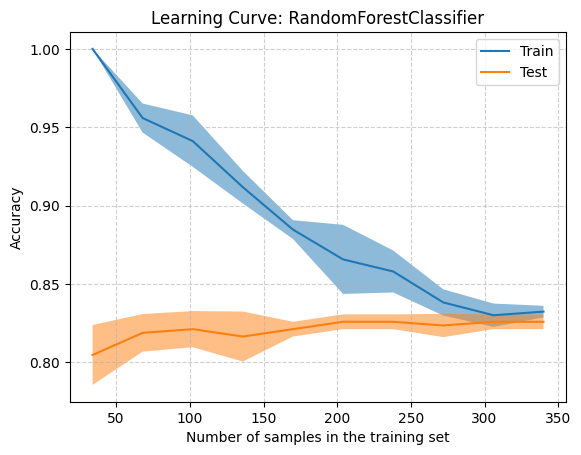

In [27]:
from sklearn.ensemble import RandomForestClassifier

params = {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
model = RandomForestClassifier(**params, n_jobs=-1)
plot_learning_curve(model, X_train_encoded, y_train, classification=True)

In [28]:
# 9. Grid Search: find best hyperparameters using the training set (use cross validation or validation set)

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 2, 4],
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, n_jobs=-1)
grid_search.fit(X_train_encoded, y_train)

print("Best params:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best params: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 100}
Best score: 0.8258823529411764


In [29]:
# Train classifier

from sklearn.ensemble import RandomForestClassifier

best_params = {'max_depth': 5, 'min_samples_leaf': 4, 'n_estimators': 100}

model = RandomForestClassifier(class_weight='balanced', **best_params)
model.fit(X_train_encoded, y_train)
y_pred = model.predict(X_test_encoded)

In [30]:
# Check score
get_classification_report(y_test, y_pred)

,precision,recall,f1-score,support
0,0.82,0.94,0.87,62.00
1,0.00,0.00,0.00,13.00
accuracy,0.77,0.77,0.77,0.77
macro avg,0.41,0.47,0.44,75.00
weighted avg,0.68,0.77,0.72,75.00


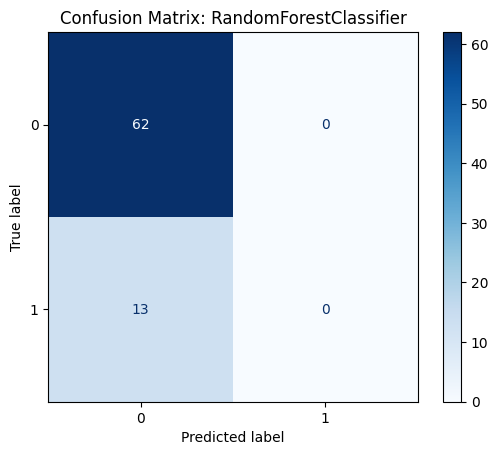

In [27]:
show_confusion_matrix(model, y_test, y_pred)

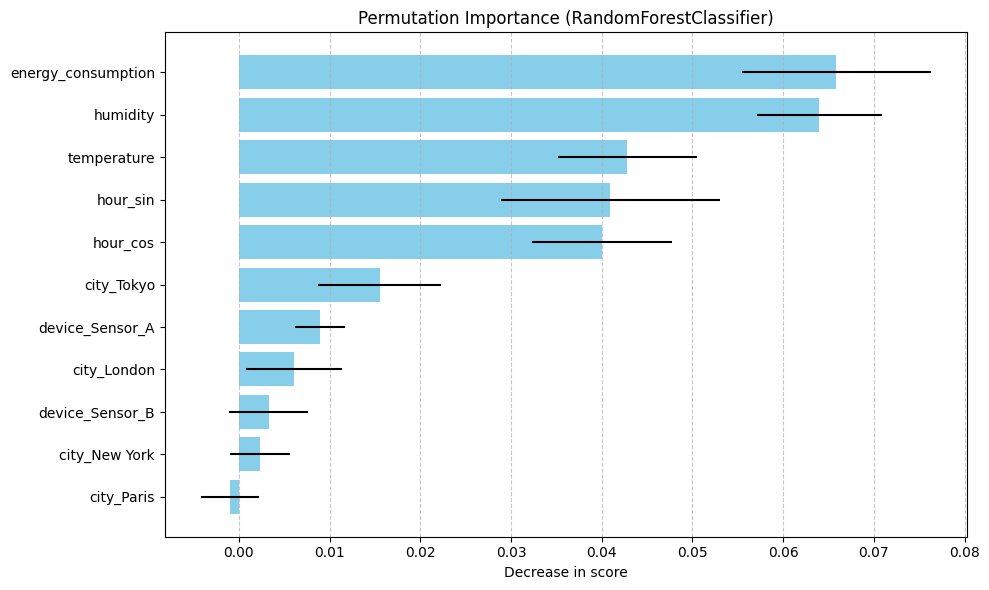

,Feature,Importance_Mean,Importance_Std
2,energy_consumption,0.065882,0.010417
1,humidity,0.064000,0.006884
0,temperature,0.042824,0.007646
3,hour_sin,0.040941,0.012053
4,hour_cos,0.040000,0.007733
8,city_Tokyo,0.015529,0.006754
9,device_Sensor_A,0.008941,0.002744
5,city_London,0.006118,0.005282
10,device_Sensor_B,0.003294,0.004364
6,city_New York,0.002353,0.003328


In [31]:
# Find and plot most important features

import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance

def check_permutation_importance(trained_model, X_test, y_test, n_repeats):
    """
    Calculates and plots permutation importance for a trained model
    """
    # Calculate importance
    result = permutation_importance(trained_model, X_test, y_test, n_repeats=n_repeats, n_jobs=-1)
    
    # Organize into a DataFrame
    importance_df = pd.DataFrame({
        "Feature": X_test.columns,
        "Importance_Mean": result.importances_mean,
        "Importance_Std": result.importances_std
    }).sort_values(by="Importance_Mean", ascending=False)
    
    # Visualization
    plt.figure(figsize=(10, 6))
    plt.barh(importance_df["Feature"], importance_df["Importance_Mean"], 
             xerr=importance_df["Importance_Std"], color='skyblue')
    plt.xlabel("Decrease in score")
    plt.title(f"Permutation Importance ({trained_model.__class__.__name__})")
    plt.gca().invert_yaxis()  # Put highest importance at the top
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    return importance_df


check_permutation_importance(model, X_train_encoded, y_train, n_repeats=5)

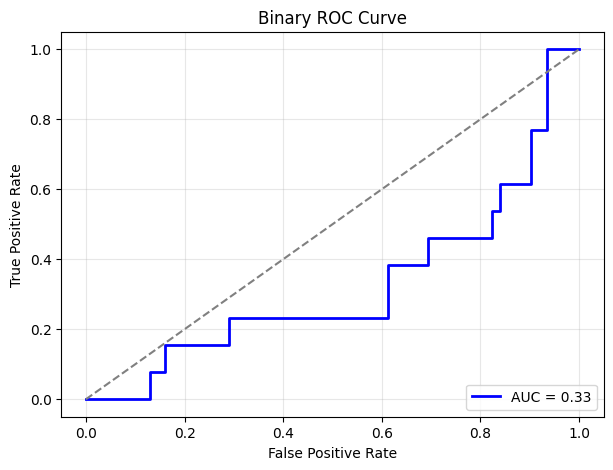

AUC: 0.3250620347394541


In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

def plot_roc_curve_binary(model, X_test, y_test):
    """
    Plots a single ROC curve for binary classification.
    """
    # Get scores (probabilities or decision function)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(y_test, y_score)
    auc = roc_auc_score(y_test, y_score)

    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'AUC = {auc:.2f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Binary ROC Curve')
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

    return auc


auc = plot_roc_curve_binary(model, X_test_encoded, y_test)
print("AUC:", auc)